### Import

In [77]:
import os
import pandas as pd
pd.options.display.float_format = '{:.3f}'.format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB
from itertools import product
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from tqdm import tqdm

from functions_utils import *
from functions_data import *
from functions_optimize import *
from functions_eval import *

In [113]:
def load_holistic_results(I, T, S, base_dir):
    """
    기존 폴더 구조 (i_{I}_s_{S}) 에서 최적화 결과를 불러오는 함수
    """
    save_dir = os.path.join(base_dir, f"i_{I}_s_{S}")
    print(f"🔄 최적화 결과 불러오는 중... (폴더: {save_dir})")
    
    results = {}
    
    # 1. x_hol 불러오기 (I × T)
    x_df = pd.read_csv(f"{save_dir}/x_hol.csv")
    x_hol = np.zeros((I, T))
    for _, row in x_df.iterrows():
        x_hol[int(row['i']), int(row['t'])] = row['x_hol']
    results['x_hol'] = x_hol
    print("✅ x_hol 불러오기 완료")
    
    # 2. a_hol 불러오기 (T,)
    a_df = pd.read_csv(f"{save_dir}/a_hol.csv")
    a_hol = np.zeros(T)
    for _, row in a_df.iterrows():
        a_hol[int(row['t'])] = row['a_hol']
    results['a_hol'] = a_hol
    print("✅ a_hol 불러오기 완료")
    
    # 3. yp_hol 불러오기 (I × T × S)
    yp_df = pd.read_csv(f"{save_dir}/yp_hol.csv")
    yp_hol = np.zeros((I, T, S))
    for _, row in yp_df.iterrows():
        yp_hol[int(row['i']), int(row['t']), int(row['s'])] = row['yp_hol']
    results['yp_hol'] = yp_hol
    print("✅ yp_hol 불러오기 완료")
    
    # 4. ym_hol 불러오기 (I × T × S)
    ym_df = pd.read_csv(f"{save_dir}/ym_hol.csv")
    ym_hol = np.zeros((I, T, S))
    for _, row in ym_df.iterrows():
        ym_hol[int(row['i']), int(row['t']), int(row['s'])] = row['ym_hol']
    results['ym_hol'] = ym_hol
    print("✅ ym_hol 불러오기 완료")
    
    # 5. z_hol 불러오기 (I × T × S)
    z_df = pd.read_csv(f"{save_dir}/z_hol.csv")
    z_hol = np.zeros((I, T, S))
    for _, row in z_df.iterrows():
        z_hol[int(row['i']), int(row['t']), int(row['s'])] = row['z_hol']
    results['z_hol'] = z_hol
    print("✅ z_hol 불러오기 완료")
    
    # 6. zc_hol 불러오기 (I × T × S)
    zc_df = pd.read_csv(f"{save_dir}/zc_hol.csv")
    zc_hol = np.zeros((I, T, S))
    for _, row in zc_df.iterrows():
        zc_hol[int(row['i']), int(row['t']), int(row['s'])] = row['zc_hol']
    results['zc_hol'] = zc_hol
    print("✅ zc_hol 불러오기 완료")
    
    # 7. zd_hol 불러오기 (I × T × S)
    zd_df = pd.read_csv(f"{save_dir}/zd_hol.csv")
    zd_hol = np.zeros((I, T, S))
    for _, row in zd_df.iterrows():
        zd_hol[int(row['i']), int(row['t']), int(row['s'])] = row['zd_hol']
    results['zd_hol'] = zd_hol
    print("✅ zd_hol 불러오기 완료")
    
    # 8. ep_hol 불러오기 (I × T × S)
    ep_df = pd.read_csv(f"{save_dir}/ep_hol.csv")
    ep_hol = np.zeros((I, T, S))
    for _, row in ep_df.iterrows():
        ep_hol[int(row['i']), int(row['t']), int(row['s'])] = row['ep_hol']
    results['ep_hol'] = ep_hol
    print("✅ ep_hol 불러오기 완료")
    
    # 9. bp_hol 불러오기 (T × S)
    bp_df = pd.read_csv(f"{save_dir}/bp_hol.csv")
    bp_hol = np.zeros((T, S))
    for _, row in bp_df.iterrows():
        bp_hol[int(row['t']), int(row['s'])] = row['bp_hol']
    results['bp_hol'] = bp_hol
    print("✅ bp_hol 불러오기 완료")
    
    # 10. em_hol 불러오기 (I × T × S)
    em_df = pd.read_csv(f"{save_dir}/em_hol.csv")
    em_hol = np.zeros((I, T, S))
    for _, row in em_df.iterrows():
        em_hol[int(row['i']), int(row['t']), int(row['s'])] = row['em_hol']
    results['em_hol'] = em_hol
    print("✅ em_hol 불러오기 완료")
    
    # 11. bm_hol 불러오기 (T × S)
    bm_df = pd.read_csv(f"{save_dir}/bm_hol.csv")
    bm_hol = np.zeros((T, S))
    for _, row in bm_df.iterrows():
        bm_hol[int(row['t']), int(row['s'])] = row['bm_hol']
    results['bm_hol'] = bm_hol
    print("✅ bm_hol 불러오기 완료")
    
    # 12. d_hol 불러오기 (I × I × T × S)
    d_df = pd.read_csv(f"{save_dir}/d_hol.csv")
    d_hol = np.zeros((I, I, T, S))
    for _, row in d_df.iterrows():
        d_hol[int(row['i']), int(row['j']), int(row['t']), int(row['s'])] = row['d_hol']
    results['d_hol'] = d_hol
    print("✅ d_hol 불러오기 완료")
    
    # 13. dp_hol 불러오기 (I × T × S)
    dp_df = pd.read_csv(f"{save_dir}/dp_hol.csv")
    dp_hol = np.zeros((I, T, S))
    for _, row in dp_df.iterrows():
        dp_hol[int(row['i']), int(row['t']), int(row['s'])] = row['dp_hol']
    results['dp_hol'] = dp_hol
    print("✅ dp_hol 불러오기 완료")
    
    # 14. dm_hol 불러오기 (I × T × S)
    dm_df = pd.read_csv(f"{save_dir}/dm_hol.csv")
    dm_hol = np.zeros((I, T, S))
    for _, row in dm_df.iterrows():
        dm_hol[int(row['i']), int(row['t']), int(row['s'])] = row['dm_hol']
    results['dm_hol'] = dm_hol
    print("✅ dm_hol 불러오기 완료")
    
    # 15. obj_hol 불러오기 (스칼라)
    obj_df = pd.read_csv(f"{save_dir}/obj_hol.csv")
    obj_hol = obj_df['obj_hol'].iloc[0]
    results['obj_hol'] = obj_hol
    print("✅ obj_hol 불러오기 완료")
    
    print(f"🎉 모든 변수 불러오기 완료!")
    return results

def load_scenario_data_legacy(I, T, S, base_dir):
    """
    기존 폴더 구조 (i_{I}_s_{S}) 에서 시나리오 데이터를 불러오는 함수
    """
    save_dir = os.path.join(base_dir, f"i_{I}_s_{S}")
    print(f"🔄 시나리오 데이터 불러오는 중... (폴더: {save_dir})")
    
    results = {}
    
    # 1. R 불러오기 (I × T × S)
    R_df = pd.read_csv(f"{save_dir}/R.csv")
    R = np.zeros((I, T, S))
    for _, row in R_df.iterrows():
        R[int(row['i']), int(row['t']), int(row['s'])] = row['R']
    results['R'] = R
    print("✅ R 불러오기 완료")
    
    # 2. P_DA 불러오기 (T,)
    P_DA_df = pd.read_csv(f"{save_dir}/P_DA.csv")
    P_DA = np.zeros(T)
    for _, row in P_DA_df.iterrows():
        P_DA[int(row['t'])] = row['P_DA']
    results['P_DA'] = P_DA
    print("✅ P_DA 불러오기 완료")
    
    # 3. P_RT 불러오기 (T × S)
    P_RT_df = pd.read_csv(f"{save_dir}/P_RT.csv")
    P_RT = np.zeros((T, S))
    for _, row in P_RT_df.iterrows():
        P_RT[int(row['t']), int(row['s'])] = row['P_RT']
    results['P_RT'] = P_RT
    print("✅ P_RT 불러오기 완료")
    
    # 4. P_PN 불러오기 (T,) - 기존 버전은 t만 있었음
    P_PN_df = pd.read_csv(f"{save_dir}/P_PN.csv")
    P_PN = np.zeros(T)
    for _, row in P_PN_df.iterrows():
        P_PN[int(row['t'])] = row['P_PN']
    results['P_PN'] = P_PN
    print("✅ P_PN 불러오기 완료")
    
    print(f"🎉 모든 시나리오 데이터 불러오기 완료!")
    return results

In [123]:
I = 5; T = 24; S = 200

In [124]:
BASE_PATH = "/Users/jangseohyun/SynologyDrive/workspace/symply/DER/opt_result_past"

loaded_results = load_holistic_results(I, T, S, base_dir=BASE_PATH)

x = loaded_results['x_hol']; a = loaded_results['a_hol']
yp = loaded_results['yp_hol']; ym = loaded_results['ym_hol']
z = loaded_results['z_hol']; zc = loaded_results['zc_hol']; zd = loaded_results['zd_hol']
ep = loaded_results['ep_hol']; bp = loaded_results['bp_hol']
em = loaded_results['em_hol']; bm = loaded_results['bm_hol']
d = loaded_results['d_hol']; dp = loaded_results['dp_hol']; dm = loaded_results['dm_hol']
obj = loaded_results['obj_hol']

scenario_data = load_scenario_data_legacy(I, T, S, base_dir=BASE_PATH)
R = scenario_data['R']; P_DA = scenario_data['P_DA']; P_RT = scenario_data['P_RT']; P_PN = scenario_data['P_PN']

🔄 최적화 결과 불러오는 중... (폴더: /Users/jangseohyun/SynologyDrive/workspace/symply/DER/opt_result_past/i_5_s_200)
✅ x_hol 불러오기 완료
✅ a_hol 불러오기 완료
✅ yp_hol 불러오기 완료
✅ ym_hol 불러오기 완료
✅ z_hol 불러오기 완료
✅ zc_hol 불러오기 완료
✅ zd_hol 불러오기 완료
✅ ep_hol 불러오기 완료
✅ bp_hol 불러오기 완료
✅ em_hol 불러오기 완료
✅ bm_hol 불러오기 완료
✅ d_hol 불러오기 완료
✅ dp_hol 불러오기 완료
✅ dm_hol 불러오기 완료
✅ obj_hol 불러오기 완료
🎉 모든 변수 불러오기 완료!
🔄 시나리오 데이터 불러오는 중... (폴더: /Users/jangseohyun/SynologyDrive/workspace/symply/DER/opt_result_past/i_5_s_200)
✅ R 불러오기 완료
✅ P_DA 불러오기 완료
✅ P_RT 불러오기 완료
✅ P_PN 불러오기 완료
🎉 모든 시나리오 데이터 불러오기 완료!


### Results

In [125]:
import matplotlib.pyplot as plt
import numpy as np

def plot_scenarios_histogram(dp, dm, P_PN, P_RT, I, T, S, selected_i, selected_t):
    """
    특정 DER i와 특정 시간 t에 대해 모든 시나리오 s의 데이터를 히스토그램으로 플롯
    """
    
    # 특정 i, t에 대한 모든 시나리오 s의 데이터 추출
    dp_data = [dp[selected_i, selected_t, s] for s in range(S)]  # S개
    dm_data = [dm[selected_i, selected_t, s] for s in range(S)]  # S개
    P_PN_data = [P_PN[selected_t] for s in range(S)]  # S개 (모두 같은 값)
    P_RT_data = [P_RT[selected_t, s] for s in range(S)]  # S개
    
    # 그래프 설정
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # x축 스케일 통일을 위해 dp, dm의 범위 계산
    min_dp, max_dp = int(np.floor(min(dp_data))), int(np.ceil(max(dp_data)))
    min_dm, max_dm = int(np.floor(min(dm_data))), int(np.ceil(max(dm_data)))
    
    # 더 큰 범위로 통일
    x_min = min(min_dp, min_dm)
    x_max = max(max_dp, max_dm)
    
    # 첫 번째 그래프: dp 히스토그램 (bin 너비 = 1)
    bins_dp = np.arange(min_dp, max_dp + 2) - 0.5  # dp 데이터 범위의 bins
    
    ax1.hist(dp_data, bins=bins_dp, alpha=0.7, color='blue', edgecolor='black')
    ax1.set_xlabel('dp (Total Outgoing Exchange)', fontsize=12)
    ax1.set_ylabel('Number of Scenarios', fontsize=12)
    ax1.set_title(f'dp Distribution (DER {selected_i}, t={selected_t}, P_PN={P_PN_data[0]:.2f})', fontsize=14)
    ax1.set_xlim(x_min - 0.5, x_max + 0.5)  # 통일된 x축 범위
    ax1.grid(True, alpha=0.3)
    # ax1.legend()
    
    # 두 번째 그래프: dm 히스토그램 (bin 너비 = 1)
    bins_dm = np.arange(min_dm, max_dm + 2) - 0.5  # dm 데이터 범위의 bins
    
    ax2.hist(dm_data, bins=bins_dm, alpha=0.7, color='red', edgecolor='black')
    ax2.set_xlabel('dm (Total Incoming Exchange)', fontsize=12)
    ax2.set_ylabel('Number of Scenarios', fontsize=12)
    ax2.set_title(f'dm Distribution (DER {selected_i}, t={selected_t}, P_RT varies)', fontsize=14)
    ax2.set_xlim(x_min - 0.5, x_max + 0.5)  # 통일된 x축 범위
    ax2.grid(True, alpha=0.3)
    # ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 통계 정보 출력
    # print(f"\n📊 히스토그램 분석 결과 (DER {selected_i}, t={selected_t})")
    # print(f"총 데이터 포인트: {S}개 (모든 시나리오)")
    # print(f"dp 평균: {np.mean(dp_data):.3f}, 표준편차: {np.std(dp_data):.3f}")
    # print(f"dp 범위: {min(dp_data):.3f} ~ {max(dp_data):.3f}")
    # print(f"P_RT 평균: {np.mean(P_RT_data):.3f}, 표준편차: {np.std(P_RT_data):.3f}")
    # print(f"P_RT 범위: {min(P_RT_data):.3f} ~ {max(P_RT_data):.3f}")
    # print(f"P_PN 값: {P_PN_data[0]:.3f} (고정)")

def plot_scenarios_scatter(dp, dm, P_PN, P_RT, I, T, S, selected_i, selected_t):
    """
    특정 DER i와 특정 시간 t에 대해 모든 시나리오 s의 데이터를 스캐터 플롯으로 플롯
    """
    
    # 특정 i, t에 대한 모든 시나리오 s의 데이터 추출
    dp_data = [dp[selected_i, selected_t, s] for s in range(S)]  # S개
    dm_data = [dm[selected_i, selected_t, s] for s in range(S)]  # S개
    P_PN_data = [P_PN[selected_t] for s in range(S)]  # S개 (모두 같은 값)
    P_RT_data = [P_RT[selected_t, s] for s in range(S)]  # S개
    
    # 그래프 설정
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # 첫 번째 그래프: dp vs P_PN 스캐터 플롯
    ax1.scatter(dp_data, P_PN_data, alpha=0.7, s=30, c='blue', edgecolors='black')
    ax1.set_xlabel('dp (Total Outgoing Exchange)', fontsize=12)
    ax1.set_ylabel('P_PN (Penalty Price)', fontsize=12)
    ax1.set_title(f'dp vs P_PN (DER {selected_i}, t={selected_t}, {S} scenarios)', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # 두 번째 그래프: dm vs P_RT 스캐터 플롯
    ax2.scatter(dm_data, P_RT_data, alpha=0.7, s=30, c='red', edgecolors='black')
    ax2.set_xlabel('dm (Total Incoming Exchange)', fontsize=12)
    ax2.set_ylabel('P_RT (Real-Time Price)', fontsize=12)
    ax2.set_title(f'dm vs P_RT (DER {selected_i}, t={selected_t}, {S} scenarios)', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # # 통계 정보 출력
    # print(f"\n📊 스캐터 플롯 분석 결과 (DER {selected_i}, t={selected_t})")
    # print(f"총 데이터 포인트: {S}개 (모든 시나리오)")
    # print(f"dp 범위: {min(dp_data):.3f} ~ {max(dp_data):.3f}")
    # print(f"dm 범위: {min(dm_data):.3f} ~ {max(dm_data):.3f}")
    # print(f"P_PN 값: {P_PN_data[0]:.3f} (고정)")
    # print(f"P_RT 범위: {min(P_RT_data):.3f} ~ {max(P_RT_data):.3f}")
    
    # # 상관관계 분석
    # corr_dm_rt = np.corrcoef(dm_data, P_RT_data)[0, 1]
    # print(f"\n🔗 상관관계")
    # print(f"dm vs P_RT 상관계수: {corr_dm_rt:.3f}")

=== DER 0, 시간 19시 분석 ===

1️⃣ 히스토그램 버전


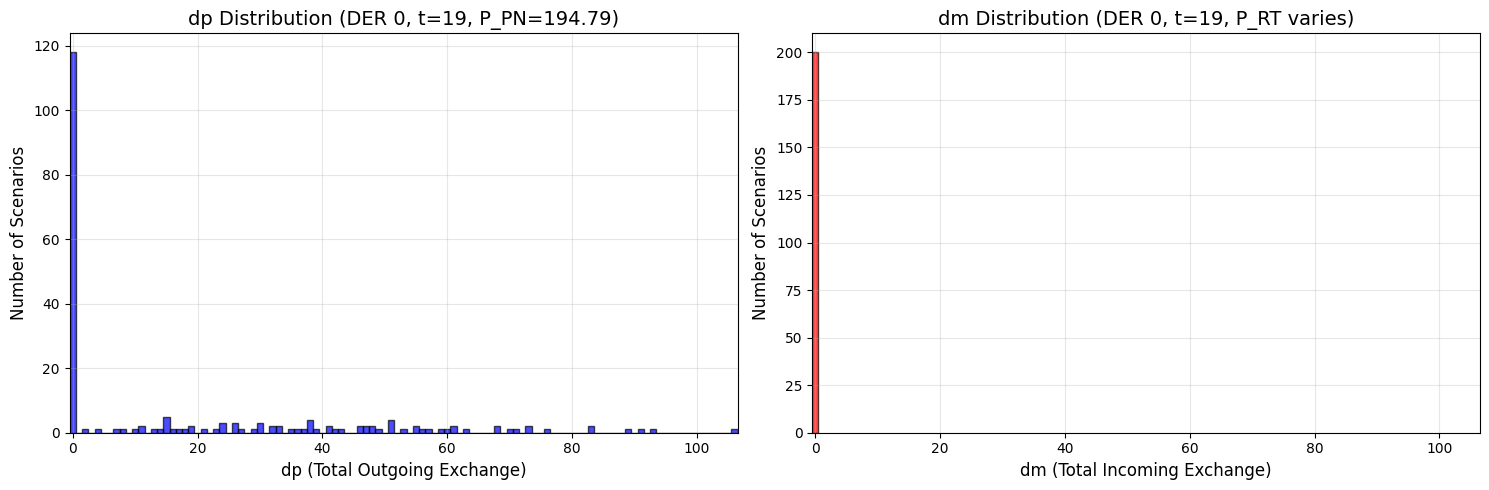

=== DER 0, 시간 20시 분석 ===

1️⃣ 히스토그램 버전


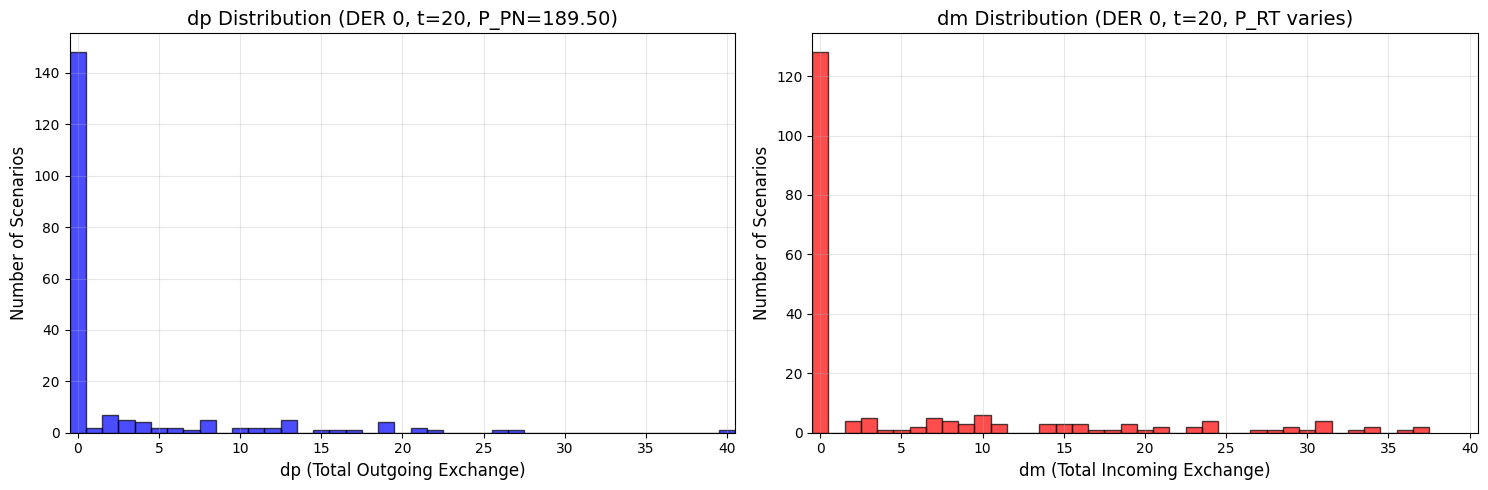

In [126]:
# for selected_i, selected_t in product(range(I), range(10,22)):
for selected_t, selected_i in product(range(19,21), range(0,1)):
    print(f"=== DER {selected_i}, 시간 {selected_t}시 분석 ===")

    print(f"\n1️⃣ 히스토그램 버전")
    plot_scenarios_histogram(dp, dm, P_PN, P_RT, I, T, S, selected_i, selected_t)

    # print(f"\n2️⃣ 스캐터 플롯 버전")
    # plot_scenarios_scatter(dp, dm, P_PN, P_RT, I, T, S, selected_i, selected_t)

In [127]:
def plot_dm_rt_scatter(dm, P_RT, I, T, S, selected_i, selected_t):
    """
    특정 DER i와 특정 시간 t에 대해 dm vs P_RT 스캐터 플롯 (P_RT 구간별 색깔)
    """
    
    # 특정 i, t에 대한 모든 시나리오 s의 데이터 추출
    dm_data = [dm[selected_i, selected_t, s] for s in range(S)]  # S개
    P_RT_data = [P_RT[selected_t, s] for s in range(S)]  # S개
    
    # 그래프 설정
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    
    # P_RT 범위를 구간으로 나누기
    min_rt, max_rt = min(P_RT_data), max(P_RT_data)
    n_bins = 5  # 5개 구간으로 나누기
    
    if min_rt == max_rt:
        # 모든 P_RT가 같으면 한 색깔로
        ax.scatter(dm_data, P_RT_data, alpha=0.7, s=30, c='red', edgecolors='black', 
                  label=f'P_RT={min_rt:.2f}')
    else:
        # P_RT 구간 정의
        bin_edges = np.linspace(min_rt, max_rt, n_bins + 1)
        colors = ['blue', 'green', 'orange', 'red', 'purple']
        
        for i_bin in range(n_bins):
            # 각 구간에 속하는 시나리오 찾기
            mask = (np.array(P_RT_data) >= bin_edges[i_bin]) & (np.array(P_RT_data) < bin_edges[i_bin + 1])
            if i_bin == n_bins - 1:  # 마지막 구간은 최댓값 포함
                mask = (np.array(P_RT_data) >= bin_edges[i_bin]) & (np.array(P_RT_data) <= bin_edges[i_bin + 1])
            
            if np.any(mask):
                dm_bin = np.array(dm_data)[mask]
                rt_bin = np.array(P_RT_data)[mask]
                
                ax.scatter(dm_bin, rt_bin, alpha=0.7, s=30, c=colors[i_bin], 
                          edgecolors='black', 
                          label=f'P_RT: {bin_edges[i_bin]:.1f}-{bin_edges[i_bin+1]:.1f}')
    
    ax.set_xlabel('dm (Total Incoming Exchange)', fontsize=12)
    ax.set_ylabel('P_RT (Real-Time Price)', fontsize=12)
    ax.set_title(f'dm vs P_RT (DER {selected_i}, t={selected_t}, {S} scenarios)', fontsize=14)
    ax.grid(True, alpha=0.3)
    # ax.legend()
    
    plt.tight_layout()
    plt.show()

In [129]:
# for selected_i, selected_t in product(range(I), range(10,22)):
# for selected_t, selected_i in product(range(20, 21), range(9, 10)):
#     print(f"=== DER {selected_i}, 시간 {selected_t}시 분석 ===")
#     plot_dm_rt_scatter(dm, P_RT, I, T, S, selected_i, selected_t)

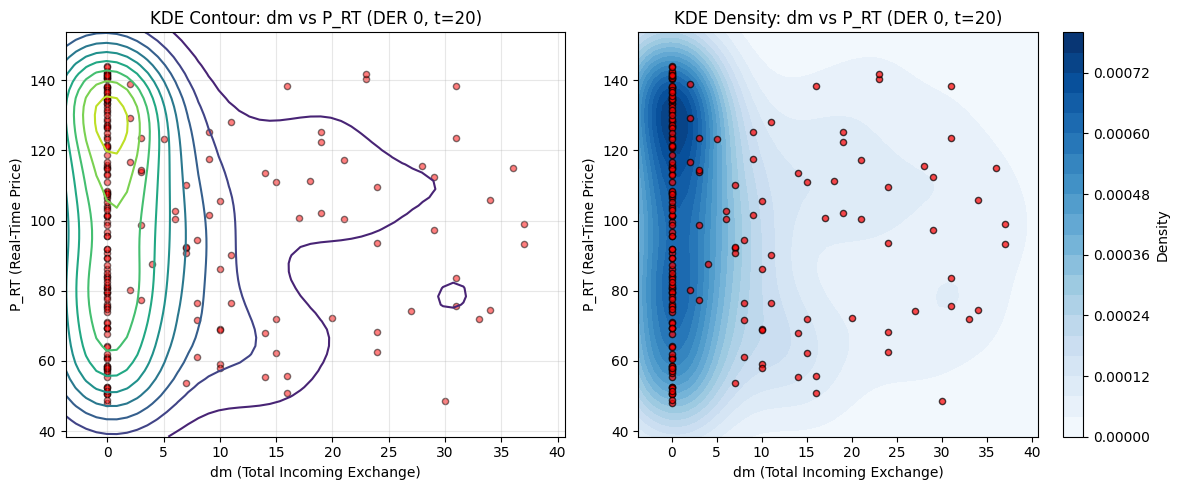

생성된 유효 샘플 수: 200
dm 범위: 0.117 ~ 42.283
P_RT 범위: 36.549 ~ 170.347


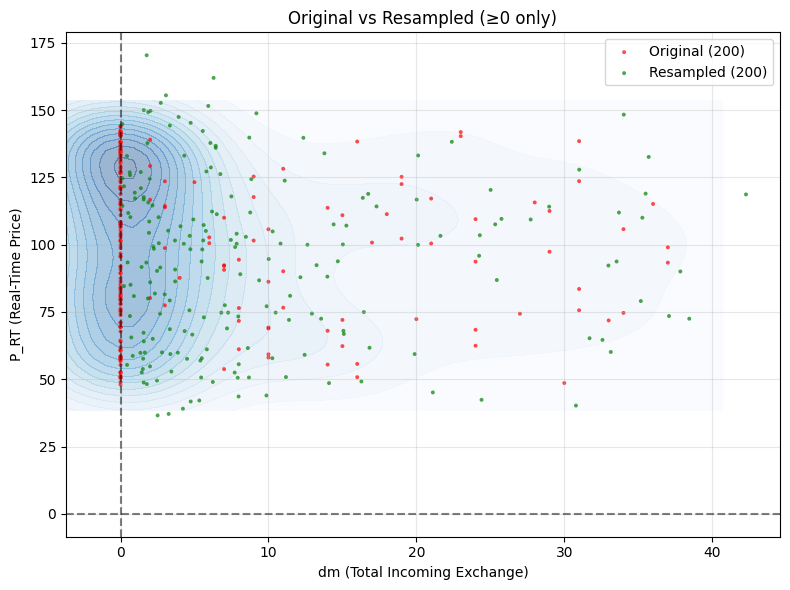

In [131]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

# 특정 DER i와 시간 t 선택
selected_i = 0
selected_t = 20

# 해당 i, t에 대한 모든 시나리오의 데이터 추출
dm_data = [dm[selected_i, selected_t, s] for s in range(S)]  # S개
P_RT_data = [P_RT[selected_t, s] for s in range(S)]  # S개

# KDE 생성
data_points = np.vstack([dm_data, P_RT_data])  # 2 x S 배열
kde = gaussian_kde(data_points)

# 격자 생성 (더 조밀하게)
x_min, x_max = min(dm_data), max(dm_data)
y_min, y_max = min(P_RT_data), max(P_RT_data)

# 격자 범위를 약간 확장
x_range = x_max - x_min
y_range = y_max - y_min
x_min -= x_range * 0.1
x_max += x_range * 0.1
y_min -= y_range * 0.1
y_max += y_range * 0.1

# 격자 생성
x_grid, y_grid = np.mgrid[x_min:x_max:50j, y_min:y_max:50j]
positions = np.vstack([x_grid.ravel(), y_grid.ravel()])

# 각 격자점에서의 density 계산
density = kde(positions).reshape(x_grid.shape)

# 시각화
plt.figure(figsize=(12, 5))

# 1. Contour plot
plt.subplot(1, 2, 1)
plt.contour(x_grid, y_grid, density, levels=10)
plt.scatter(dm_data, P_RT_data, alpha=0.5, s=20, c='red', edgecolors='black')
plt.xlabel('dm (Total Incoming Exchange)')
plt.ylabel('P_RT (Real-Time Price)')
plt.title(f'KDE Contour: dm vs P_RT (DER {selected_i}, t={selected_t})')
plt.grid(True, alpha=0.3)

# 2. Filled contour plot
plt.subplot(1, 2, 2)
plt.contourf(x_grid, y_grid, density, levels=20, cmap='Blues')
plt.colorbar(label='Density')
plt.scatter(dm_data, P_RT_data, alpha=0.7, s=20, c='red', edgecolors='black')
plt.xlabel('dm (Total Incoming Exchange)')
plt.ylabel('P_RT (Real-Time Price)')
plt.title(f'KDE Density: dm vs P_RT (DER {selected_i}, t={selected_t})')

plt.tight_layout()
plt.show()

# KDE에서 새로운 샘플 생성 (옵션)
n_samples = 200
max_attempts = n_samples * 10  # 충분히 많은 시도

valid_samples = []
attempts = 0

while len(valid_samples) < n_samples and attempts < max_attempts:
    # 더 많은 샘플을 생성해서 필터링
    batch_size = min(100, n_samples - len(valid_samples) + 50)
    samples = kde.resample(batch_size)
    
    # 0 이상 조건 확인
    valid_mask = (samples[0] >= 0) & (samples[1] >= 0)
    valid_batch = samples[:, valid_mask]
    
    if valid_batch.shape[1] > 0:
        valid_samples.append(valid_batch)
    
    attempts += batch_size

# 유효한 샘플들 결합
if valid_samples:
    all_valid = np.hstack(valid_samples)
    n_valid = min(n_samples, all_valid.shape[1])
    
    new_dm = all_valid[0, :n_valid]
    new_P_RT = all_valid[1, :n_valid]
    
    print(f"생성된 유효 샘플 수: {len(new_dm)}")
    print(f"dm 범위: {new_dm.min():.3f} ~ {new_dm.max():.3f}")
    print(f"P_RT 범위: {new_P_RT.min():.3f} ~ {new_P_RT.max():.3f}")
else:
    print("유효한 샘플을 생성할 수 없습니다.")
    new_dm, new_P_RT = [], []

# 시각화 (유효 샘플이 있을 때만)
if len(new_dm) > 0:
    plt.figure(figsize=(8, 6))
    plt.contourf(x_grid, y_grid, density, levels=15, cmap='Blues', alpha=0.4)
    plt.scatter(dm_data, P_RT_data, alpha=0.7, s=8, c='red', edgecolors='none',
              label=f'Original ({len(dm_data)})')
    plt.scatter(new_dm, new_P_RT, alpha=0.7, s=8, c='green', edgecolors='none',
              label=f'Resampled ({len(new_dm)})')
    plt.xlabel('dm (Total Incoming Exchange)')
    plt.ylabel('P_RT (Real-Time Price)')
    plt.title('Original vs Resampled (≥0 only)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 0 이상 구간 표시
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

In [137]:
profit_data = []

for i in range(I):
    da_revenue = np.sum(x[i, :] * P_DA)
    yp_revenue = np.mean([np.sum(yp[i, :, s] * P_RT[:, s]) for s in range(S)])
    ym_penalty = np.mean([np.sum(ym[i, :, s] * P_PN) for s in range(S)])
    dp_revenue = np.mean([np.sum(dp[i, :, s] * P_PN) for s in range(S)])
    dm_cost = np.mean([np.sum(dm[i, :, s] * P_RT[:, s]) for s in range(S)])
    total_profit = da_revenue + yp_revenue - ym_penalty + dp_revenue - dm_cost
    # total_profit = da_revenue + ep_revenue - em_penalty

    profit_data.append({
        'DER_id': i,
        'DA_revenue': da_revenue,
        'YP_revenue': yp_revenue,
        'YM_penalty': ym_penalty,
        'DP_revenue': dp_revenue,
        'DM_cost': dm_cost,
        'Total_profit': total_profit
    })

profit_df = pd.DataFrame(profit_data)
summary_row = {
    'DER_id': 'TOTAL',
    'DA_revenue': profit_df['DA_revenue'].sum(),
    'YP_revenue': profit_df['YP_revenue'].sum(),
    'YM_penalty': profit_df['YM_penalty'].sum(),
    'DP_revenue': profit_df['DP_revenue'].sum(),
    'DM_cost': profit_df['DM_cost'].sum(),
    'Total_profit': profit_df['Total_profit'].sum()
}
profit_df = pd.concat([profit_df, pd.DataFrame([summary_row])], ignore_index=True)
pd.DataFrame(profit_df)

,DER_id,DA_revenue,YP_revenue,YM_penalty,DP_revenue,DM_cost,Total_profit
0,0,208782.730,183628.834,251521.215,4016.753,130916.366,13990.736
1,1,379.002,354951.035,0.000,61808.456,0.000,417138.493
2,2,25784.031,394798.592,5763.492,72490.501,2895.301,484414.331
3,3,38361.388,453102.224,11595.691,92854.917,6069.262,566653.576
4,4,1235.000,192436.198,1241.175,30089.775,580.419,221939.379
5,TOTAL,274542.151,1578916.883,270121.573,261260.402,140461.347,1704136.515
